# Model 4: Gradient Boosted Trees (OneVsRest)
## IoT Saldırı Tipi Sınıflandırması (Multi-class)

Bu notebook, **Edge-IIoTset** veri seti üzerinde **Attack_type** kolonunu hedef değişken olarak kullanan
Gradient Boosted Trees (GBT) modelini **OneVsRest** wrapper ile adım adım eğitir ve değerlendirir.

### Neden GBT?
- **Boosting**: Zayıf öğrenicileri sıralı olarak güçlendirerek yüksek doğruluk elde eder
- **Gradient tabanlı optimizasyon**: Her yeni ağaç önceki hataları düzeltir
- **Yüksek performans**: Çoğu tabular veri yarışmasında en iyi sonuçlardan birini verir
- **Feature importance**: Ağaçların birleşik katkısı ile güvenilir önem skoru

### OneVsRest Neden Gerekli?
Spark MLlib'in `GBTClassifier`'ı **doğrudan multi-class desteklemez**. Bu yüzden `OneVsRest` wrapper kullanılır:
- N sınıf → N adet binary GBT eğitilir
- Her sınıf için "bu sınıf mı / değil mi" şeklinde binary sınıflandırma yapılır
- En yüksek skoru veren sınıf tahmin olarak seçilir
- **Dezavantaj**: N kat daha yavaş eğitim

### Pipeline Adımları
1. Gold Delta Lake → Veri yükleme
2. Feature vektörleme + StringIndexer
3. Sınıf ağırlıkları (classWeight)
4. Stratified Train/Test split (%80/%20)
5. GBTClassifier + OneVsRest
6. CrossValidator ile hiperparametre arama (maxIter, maxDepth)
7. Test seti değerlendirme
8. Feature importance (sınıflar arası ortalama)
9. MLflow loglama

## 1. Kütüphaneler ve Spark Session

In [1]:
import sys
import time
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pyspark.ml import Pipeline
from pyspark.ml.classification import GBTClassifier, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

sys.path.insert(0, "/opt/bitnami/spark")

from spark.spark_session import get_spark
from ml.utils import (
    run_ml_pipeline_multiclass,
    evaluate_model_multiclass,
    compute_confusion_matrix_multiclass,
    log_to_mlflow,
)

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


In [2]:
spark = get_spark("Notebook-GBT-OneVsRest-Multiclass")
print(f"Spark version: {spark.version}")
print(f"App name: {spark.sparkContext.appName}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/13 17:17:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.4.2
App name: Notebook-GBT-OneVsRest-Multiclass


## 2. Veri Yükleme ve Feature Hazırlığı

In [3]:
SAMPLE_SIZE = 30000  # Hızlı test için (None = tüm veri)

stage_start = time.perf_counter()
train_df, test_df, feature_cols, label_index_model = run_ml_pipeline_multiclass(
    spark,
    sample_size=SAMPLE_SIZE,
    split_log_stats=True,
)
label_names = list(label_index_model.labels)
num_classes = len(label_names)

print(f"\nPipeline süresi: {time.perf_counter() - stage_start:.2f}s")
print(f"Feature sayısı: {len(feature_cols)}")
print(f"Sınıf sayısı: {num_classes}")
print(f"Sınıflar: {label_names}")
print(f"\nOneVsRest ile {num_classes} adet binary GBT eğitilecek.")


🧱 Multi-class ML pipeline başlatıldı...
✅ MLflow bağlantısı kuruldu: http://mlflow-server:5000
   Experiment: iot_intrusion_detection
   ⏱️ MLflow: 1.02s
📥 Gold katmanından veri okunuyor: /opt/bitnami/spark/delta-storage/gold/ml_ready
   ✅ Okuma tamamlandı. Kolon sayısı: 65
   ⏱️ Gold okuma (lazy): 3.70s
   📊 42 numerik feature kolon seçildi.
   ⏳ [1] prepare_features_multiclass (lazy)...
🔧 Multi-class feature hazırlığı: 42 feature, label='Attack_type'


26/05/13 17:17:31 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

   ✅ Multi-class hazırlık tamam (sınıf sayısı: 15).
   📚 Sınıf eşlemesi (label index → orijinal isim):
       0 → Normal
       1 → DDoS_UDP
       2 → DDoS_ICMP
       3 → Ransomware
       4 → DDoS_HTTP
       5 → SQL_injection
       6 → Uploading
       7 → DDoS_TCP
       8 → Backdoor
       9 → Vulnerability_scanner
      10 → Port_Scanning
      11 → XSS
      12 → Password
      13 → MITM
      14 → Fingerprinting
   ✅ [1] prepare_features_multiclass: 5.66s
   ⏳ [2] Tek seferlik MATERIALIZE (coalesce + persist + count)...
   ⚡ Örneklem: 157,800 → ~30,000 satır (frac=0.1901)


[Stage 19:===========================================>              (3 + 1) / 4]

   ✅ [2] Materialize tamam: 30,106 satır, 2.91s
   ⏳ [3] Multi-class class weights...


⚖️  Multi-class sınıf ağırlıkları (n=15):
   label= 0  weight=0.4240
   label= 1  weight=0.7130
   label= 2  weight=0.7461
   label= 3  weight=0.9467
   label= 4  weight=0.9834
   label= 5  weight=1.0277
   label= 6  weight=1.0716
   label= 7  weight=1.0240
   label= 8  weight=1.0168
   label= 9  weight=1.0453
   label=10  weight=1.0704
   label=11  weight=1.0653
   label=12  weight=1.0908
   label=13  weight=9.0003
   label=14  weight=9.8386
   ✅ [3] Weights: 0.38s
   ⏳ [4] randomSplit (cached'ten)...
   ✅ [4] Train: 24,236 | Test: 5,870 (0.74s)

   Sınıf dağılımı (train+test):
    0  Normal                           4,734
    1  DDoS_UDP                         2,815
    2  DDoS_ICMP                        2,690
    3  Ransomware                       2,120
    4  DDoS_HTTP                        2,041
    5  SQL_injection                    1,953
    6  Uploading                        1,873
    7  DDoS_TCP                         1,960
    8  Backdoor                         1,974


In [4]:
train_count = train_df.count()
test_count = test_df.count()
print(f"Train: {train_count:,} satır")
print(f"Test:  {test_count:,} satır")

print("\nTrain seti sınıf dağılımı:")
train_df.groupBy("label").count().orderBy("label").show()

Train: 24,236 satır
Test:  5,870 satır

Train seti sınıf dağılımı:
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 3830|
|  1.0| 2256|
|  2.0| 2196|
|  3.0| 1689|
|  4.0| 1675|
|  5.0| 1550|
|  6.0| 1487|
|  7.0| 1581|
|  8.0| 1593|
|  9.0| 1552|
| 10.0| 1486|
| 11.0| 1524|
| 12.0| 1477|
| 13.0|  177|
| 14.0|  163|
+-----+-----+



## 3. Model Pipeline Oluşturma

GBT + OneVsRest pipeline'ı:
- **GBTClassifier**: Base binary sınıflandırıcı (her sınıf için birer tane)
- **OneVsRest**: N sınıf için N tane binary GBT eğitir

### Hiperparametreler
| Parametre | Açıklama | Aranacak Değerler |
|-----------|----------|------------------|
| `maxIter` | Boosting iterasyon (ağaç) sayısı | 20, 50 |
| `maxDepth` | Her ağacın maksimum derinliği | 3, 5 |
| `stepSize` | Learning rate | 0.1 (sabit) |

**Not**: OneVsRest çok pahalı olduğu için grid sade tutulmuştur.

In [5]:
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeight",
    maxIter=30,
    maxDepth=5,
    stepSize=0.1,
    seed=42,
)

ovr = OneVsRest(
    classifier=gbt,
    labelCol="label",
    featuresCol="features",
    weightCol="classWeight",
    parallelism=1,  # Binary GBT'ler sıralı eğitilsin (RAM dostu)
)

pipeline = Pipeline(stages=[ovr])
print("Pipeline oluşturuldu: GBTClassifier + OneVsRest")
print(f"Her fold'da {num_classes} binary GBT eğitilecek.")

Pipeline oluşturuldu: GBTClassifier + OneVsRest
Her fold'da 15 binary GBT eğitilecek.


## 4. Cross Validation

In [6]:
max_iter_values = [20, 50]
max_depth_values = [3, 5]
num_folds = 2

param_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxIter, max_iter_values)
    .addGrid(gbt.maxDepth, max_depth_values)
    .build()
)

cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1",
    ),
    numFolds=num_folds,
    seed=42,
    parallelism=2,
)

total_cv_runs = len(param_grid) * num_folds * num_classes
print(f"Grid boyutu: {len(param_grid)} kombinasyon")
print(f"Fold sayısı: {num_folds}")
print(f"OneVsRest çarpanı: {num_classes} sınıf")
print(f"Toplam binary GBT fit: {total_cv_runs}")

Grid boyutu: 4 kombinasyon
Fold sayısı: 2
OneVsRest çarpanı: 15 sınıf
Toplam binary GBT fit: 120


## 5. Model Eğitimi

**Uyarı**: OneVsRest + GBT eğitimi diğer modellere kıyasla çok daha uzun sürer.

In [7]:
print("Cross Validation başlatılıyor (OneVsRest — uzun sürebilir)...")
cv_start = time.perf_counter()
cv_model = cv.fit(train_df)
cv_duration = time.perf_counter() - cv_start
print(f"CV tamamlandı! Süre: {cv_duration:.2f}s")

# En iyi model parametreleri
best_ovr_model = cv_model.bestModel.stages[-1]
first_sub = best_ovr_model.models[0]  # İlk binary GBT'den parametre oku
best_max_iter = int(first_sub.getOrDefault("maxIter"))
best_max_depth = int(first_sub.getOrDefault("maxDepth"))
best_step_size = float(first_sub.getOrDefault("stepSize"))

print(f"\nEn iyi parametreler:")
print(f"  maxIter:  {best_max_iter}")
print(f"  maxDepth: {best_max_depth}")
print(f"  stepSize: {best_step_size}")

Cross Validation başlatılıyor (OneVsRest — uzun sürebilir)...


26/05/13 17:18:41 WARN DAGScheduler: Broadcasting large task binary with size 1251.4 KiB
26/05/13 17:18:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/13 17:18:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/05/13 17:19:02 WARN DAGScheduler: Broadcasting large task binary with size 1774.6 KiB
26/05/13 17:19:23 WARN BlockManager: Asked to remove block broadcast_10235, which does not exist
26/05/13 17:20:50 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/05/13 17:21:43 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
26/05/13 17:22:38 WARN DAGScheduler: Broadcasting large task binary with size 1245.1 KiB
26/05/13 17:23:03 WARN DAGScheduler: Broadcasting large task binary with size 1771.0 KiB
26/05/13 17:24:44 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/05/13 17:25:41 WARN DAGScheduler: Broadcasting large task binary with

CV tamamlandı! Süre: 598.58s

En iyi parametreler:
  maxIter:  50
  maxDepth: 5
  stepSize: 0.1


In [8]:
# CV sonuçları
avg_metrics = cv_model.avgMetrics
print("CV Sonuçları (F1-Score):")
print(f"{'#':<4} {'Parametreler':<35} {'Avg F1':>10}")
print("-" * 52)
cv_details = []
for i, (params, score) in enumerate(zip(param_grid, avg_metrics)):
    ps = ", ".join(f"{p.name}={v}" for p, v in params.items())
    marker = " ← best" if i == max(range(len(avg_metrics)), key=lambda x: avg_metrics[x]) else ""
    print(f"{i+1:<4} {ps:<35} {score:>10.4f}{marker}")
    cv_details.append({"index": i, "score": float(score), "params": ps})

cv_best_f1 = float(max(avg_metrics)) if avg_metrics else 0.0

CV Sonuçları (F1-Score):
#    Parametreler                            Avg F1
----------------------------------------------------
1    maxIter=20, maxDepth=3                  0.8920
2    maxIter=20, maxDepth=5                  0.9175
3    maxIter=50, maxDepth=3                  0.9072
4    maxIter=50, maxDepth=5                  0.9203 ← best


## 6. Test Seti Değerlendirme

In [9]:
predictions = cv_model.bestModel.transform(test_df)
metrics = evaluate_model_multiclass(predictions, num_classes=num_classes)

26/05/13 17:30:02 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:30:13 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:30:15 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:30:18 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
                                                                                


📊 Multi-class Değerlendirme Sonuçları:
   Metrik                    Değer
   ──────────────────────────────
   accuracy                 0.9148
   f1_score                 0.9150
   precision                0.9242
   recall                   0.9148

   Per-class metrikler:
   label   precision     recall         f1


26/05/13 17:30:20 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:30:23 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:30:25 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
                                                                                

   0          0.9955     0.9690     0.9821


26/05/13 17:30:28 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:30:30 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:30:33 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
                                                                                

...

   12         0.8811     0.7961     0.8365


26/05/13 17:32:02 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:32:05 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:32:07 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
                                                                                

   13         1.0000     0.4565     0.6269


26/05/13 17:32:10 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:32:13 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/13 17:32:15 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
[Stage 40339:=========================================>             (3 + 1) / 4]

   14         1.0000     0.3659     0.5357


In [10]:
confusion = compute_confusion_matrix_multiclass(predictions, label_names=label_names)

26/05/13 17:32:39 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
[Stage 40341:===========================>                           (2 + 2) / 4]


🔲 Multi-class Confusion Matrix:
                       │                Normal               DDoS_UDP              DDoS_ICMP             Ransomware              DDoS_HTTP          SQL_injection              Uploading               DDoS_TCP               Backdoor  Vulnerability_scanner          Port_Scanning                    XSS               Password                   MITM         Fingerprinting
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 Normal                │                   876                      0                      4                      0                      0                      0                     24                      0                      

26/05/13 17:32:41 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
                                                                                

In [11]:
print("\n" + "=" * 40)
print("SONUÇ ÖZETİ")
print("=" * 40)
print(f"Accuracy:  {metrics.get('accuracy', 0):.4f}")
print(f"F1-Score:  {metrics.get('f1_score', 0):.4f}")
print(f"Precision: {metrics.get('precision', 0):.4f}")
print(f"Recall:    {metrics.get('recall', 0):.4f}")


SONUÇ ÖZETİ
Accuracy:  0.9148
F1-Score:  0.9150
Precision: 0.9242
Recall:    0.9148


## 7. Feature Importance

OneVsRest'te her sınıf için ayrı bir binary GBT eğitilir. Feature importance hesaplamak için
tüm binary modellerin `featureImportances` değerlerinin **aritmetik ortalaması** alınır.

In [12]:
# OneVsRest feature importance: tüm binary GBT'lerin ortalaması
sub_models = best_ovr_model.models
n_features = len(feature_cols)
agg = [0.0] * n_features

for sm in sub_models:
    imp = sm.featureImportances.toArray().tolist()
    for j in range(n_features):
        agg[j] += imp[j] if j < len(imp) else 0.0

agg = [v / max(len(sub_models), 1) for v in agg]
fi_pairs = sorted(zip(feature_cols, agg), key=lambda x: x[1], reverse=True)
top_features = fi_pairs[:15]

print("Top 15 Feature Importance (sınıflar arası ortalama):")
print(f"{'#':<4} {'Feature':<35} {'Importance':>12}")
print("-" * 55)
for idx, (fname, importance) in enumerate(top_features, start=1):
    print(f"{idx:<4} {fname:<35} {importance:>12.6f}")

Top 15 Feature Importance (sınıflar arası ortalama):
#    Feature                               Importance
-------------------------------------------------------
1    tcp_srcport                             0.288482
2    tcp_dstport                             0.132500
3    tcp_ack                                 0.115355
4    traffic_asymmetry_ratio                 0.086681
5    udp_stream                              0.072789
6    tcp_seq                                 0.061695
7    tcp_len                                 0.057446
8    tcp_connection_rst                      0.047367
9    http_content_length                     0.041867
10   pkt_size_cv                             0.018119
11   iat_regularity                          0.017720
12   tcp_flags                               0.012605
13   tcp_ack_raw                             0.009889
14   udp_port                                0.009338
15   tcp_connection_syn                      0.006842


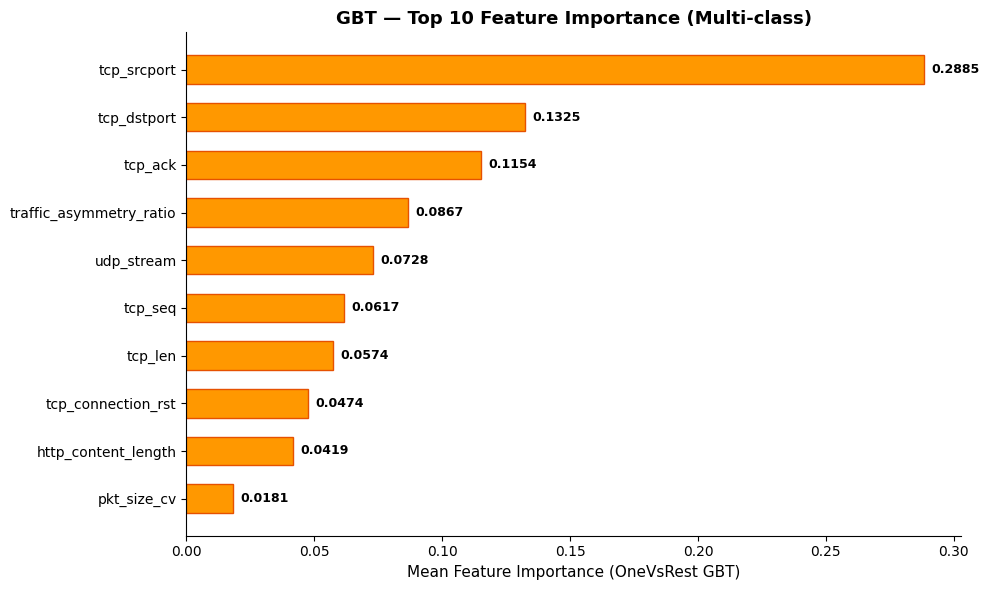

In [13]:
# Feature Importance Görselleştirmesi
top10 = fi_pairs[:10]
names = [f[0] for f in reversed(top10)]
values = [f[1] for f in reversed(top10)]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(names, values, color="#FF9800", edgecolor="#E65100", height=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + max(values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Mean Feature Importance (OneVsRest GBT)", fontsize=11)
ax.set_title("GBT — Top 10 Feature Importance (Multi-class)",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Sınıf Bazında Binary GBT Analizi

In [14]:
# Her binary GBT modeli hakkında bilgi
print(f"OneVsRest: {len(sub_models)} binary GBT modeli\n")
print(f"{'Sınıf':<25} {'Ağaç Sayısı':>12} {'Toplam Düğüm':>14}")
print("-" * 55)
for i, sm in enumerate(sub_models):
    cls_name = label_names[i] if i < len(label_names) else f"class_{i}"
    n_trees = sm.getNumTrees
    total_nodes = sm.totalNumNodes
    print(f"{cls_name:<25} {n_trees:>12} {total_nodes:>14}")

OneVsRest: 15 binary GBT modeli

Sınıf                      Ağaç Sayısı   Toplam Düğüm
-------------------------------------------------------
Normal                              50           2060
DDoS_UDP                            50            514
DDoS_ICMP                           50            538
Ransomware                          50           1882
DDoS_HTTP                           50           3012
SQL_injection                       50           2916
Uploading                           50           2954
DDoS_TCP                            50            724
Backdoor                            50           1526
Vulnerability_scanner               50           2674
Port_Scanning                       50           1268
XSS                                 50           2918
Password                            50           2956
MITM                                50            536
Fingerprinting                      50           1056


## 9. MLflow'a Loglama

In [15]:
best_params = {
    "maxIter": best_max_iter,
    "maxDepth": best_max_depth,
    "stepSize": best_step_size,
    "numClasses": int(num_classes),
    "numFolds": num_folds,
    "grid_size": len(param_grid),
    "cv_total_binary_fits": total_cv_runs,
    "wrapper": "OneVsRest",
    "weightCol": "classWeight",
    "label_column": "Attack_type",
}

metrics["cv_best_f1"] = cv_best_f1

confusion_metrics = {}
for i, name in enumerate(label_names):
    confusion_metrics[f"row_total_class_{i}"] = confusion["row_totals"][i]
    confusion_metrics[f"per_class_acc_{i}"] = confusion["per_class_acc"][i]

run_id = log_to_mlflow(
    run_name="gbt_notebook",
    model_type="GBTClassifier",
    params=best_params,
    metrics={**metrics, **confusion_metrics},
    model=cv_model.bestModel,
    feature_importance=top_features[:10],
    tags={
        "source": "notebook",
        "model_index": "4",
        "classification_type": "multiclass",
        "ensemble_method": "boosting",
        "multiclass_wrapper": "OneVsRest",
    },
)
print(f"\nMLflow Run ID: {run_id}")

2026/05/13 17:32:54 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: 'getpwuid(): uid not found: 1001'
2026/05/13 17:32:54 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Ex

   ✅ Model MLflow'a kaydedildi.

✅ MLflow logging tamamlandı!
   Run ID:   49d235ae111649cf9061b2640b66fa1b
   Run Name: gbt_notebook
   UI:       http://localhost:5000
🏃 View run gbt_notebook at: http://mlflow-server:5000/#/experiments/1/runs/49d235ae111649cf9061b2640b66fa1b
🧪 View experiment at: http://mlflow-server:5000/#/experiments/1

MLflow Run ID: 49d235ae111649cf9061b2640b66fa1b


## Özet

Bu notebook'ta **Gradient Boosted Trees (OneVsRest)** modelini başarıyla eğittik:

- **Boosting** yöntemi ile sıralı olarak hataları düzelten ağaçlar eğitildi
- **OneVsRest** wrapper ile multi-class problemi N binary probleme dönüştürüldü
- **CrossValidator** ile maxIter ve maxDepth optimize edildi
- **classWeight** ile sınıf dengesizliği telafi edildi
- Binary GBT'lerin birleşik **feature importance** analizi yapıldı
- Sonuçlar **MLflow**'a loglandı

GBT, genellikle en yüksek doğruluğu veren model olmakla birlikte, OneVsRest nedeniyle eğitim süresi uzundur.

In [16]:
spark.stop()
print("Spark oturumu kapatıldı.")

Spark oturumu kapatıldı.
